In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

master_df = pd.read_csv(
    "../data/processed/master_stock_data.csv"
)

In [2]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10374 entries, 0 to 10373
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     10374 non-null  object 
 1   Close    10374 non-null  float64
 2   High     10374 non-null  float64
 3   Low      10374 non-null  float64
 4   Open     10374 non-null  float64
 5   Volume   10374 non-null  int64  
 6   Company  10374 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 567.5+ KB


In [3]:
master_df['Date'] = pd.to_datetime(
    master_df['Date']
)

master_df.head()

,Date,Close,High,Low,Open,Volume,Company
0,2019-01-01,496.196381,498.985034,491.371654,498.077624,9746670,Reliance
1,2019-01-02,489.733887,498.852220,487.343625,493.319235,15628818,Reliance
2,2019-01-03,483.691925,493.363540,482.518940,490.220816,16288287,Reliance
3,2019-01-04,486.303436,488.870748,478.535167,485.750155,18516544,Reliance
4,2019-01-07,489.003540,495.067675,487.343638,489.999475,12060290,Reliance


# ==================================================
# FEATURE ENGINEERING SECTION 1 - MOVING AVERAGES
Moving averages smooth price fluctuations and help the model understand trends.
# ==================================================

In [4]:
master_df['MA_7'] = (
    master_df.groupby('Company')['Close']
    .transform(lambda x: x.rolling(window=7).mean())
)

master_df['MA_21'] = (
    master_df.groupby('Company')['Close']
    .transform(lambda x: x.rolling(window=21).mean())
)

master_df['MA_50'] = (
    master_df.groupby('Company')['Close']
    .transform(lambda x: x.rolling(window=50).mean())
)

master_df.head()

,Date,Close,High,Low,Open,Volume,Company,MA_7,MA_21,MA_50
0,2019-01-01,496.196381,498.985034,491.371654,498.077624,9746670,Reliance,NaN,NaN,NaN
1,2019-01-02,489.733887,498.852220,487.343625,493.319235,15628818,Reliance,NaN,NaN,NaN
2,2019-01-03,483.691925,493.363540,482.518940,490.220816,16288287,Reliance,NaN,NaN,NaN
3,2019-01-04,486.303436,488.870748,478.535167,485.750155,18516544,Reliance,NaN,NaN,NaN
4,2019-01-07,489.003540,495.067675,487.343638,489.999475,12060290,Reliance,NaN,NaN,NaN


In [5]:
master_df.tail()

,Date,Close,High,Low,Open,Volume,Company,MA_7,MA_21,MA_50
10369,2025-12-23,954.691650,960.241576,953.512885,959.013708,5123287,SBI,955.393258,951.450044,933.549696
10370,2025-12-24,951.793884,959.996016,950.369546,955.968634,4105643,SBI,955.631818,950.764779,935.239242
10371,2025-12-26,949.190735,953.807529,947.668191,951.793838,3286321,SBI,956.354501,949.941520,936.994601
10372,2025-12-29,947.962891,951.744759,944.426656,949.780171,5267233,SBI,954.838963,949.576669,938.545643
10373,2025-12-30,956.214172,958.915481,942.511158,945.949187,15030644,SBI,954.263620,949.317063,940.245012


In [6]:
master_df[['MA_7','MA_21','MA_50']].isnull().sum()

MA_7      36
MA_21    120
MA_50    294
dtype: int64

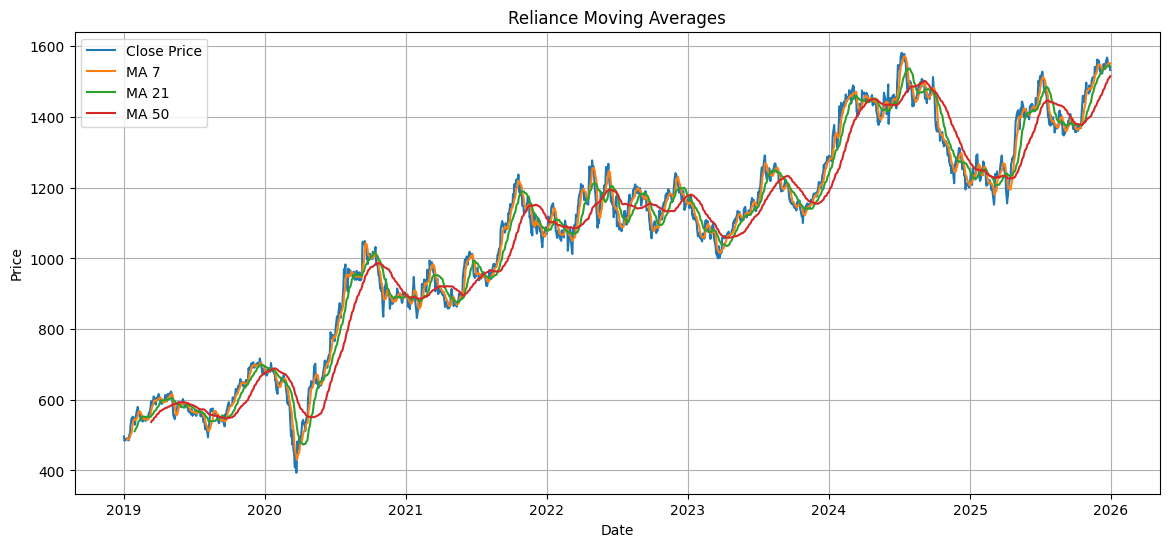

In [7]:
reliance_df = master_df[
    master_df['Company'] == 'Reliance'
]

plt.figure(figsize=(14,6))

plt.plot(
    reliance_df['Date'],
    reliance_df['Close'],
    label='Close Price'
)

plt.plot(
    reliance_df['Date'],
    reliance_df['MA_7'],
    label='MA 7'
)

plt.plot(
    reliance_df['Date'],
    reliance_df['MA_21'],
    label='MA 21'
)

plt.plot(
    reliance_df['Date'],
    reliance_df['MA_50'],
    label='MA 50'
)

plt.title('Reliance Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)

plt.show()

# ==================================================
# FEATURE ENGINEERING SECTION 2 - LAG FEATURES
"What happened yesterday often influences today."

Why do we create these?

Suppose today:

Yesterday Price = 500
5 Days Ago = 480
10 Days Ago = 450

The model can learn:

450 → 480 → 500

Price is moving upward.

This is called momentum.

Without lag features:

Model sees only today's price.

With lag features:

Model sees price history.
# ==================================================

In [8]:
master_df['Lag_1'] = (
    master_df.groupby('Company')['Close']
    .shift(1)
)

master_df['Lag_5'] = (
    master_df.groupby('Company')['Close']
    .shift(5)
)

master_df['Lag_10'] = (
    master_df.groupby('Company')['Close']
    .shift(10)
)

master_df.head()

,Date,Close,High,Low,Open,Volume,Company,MA_7,MA_21,MA_50,Lag_1,Lag_5,Lag_10
0,2019-01-01,496.196381,498.985034,491.371654,498.077624,9746670,Reliance,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-01-02,489.733887,498.852220,487.343625,493.319235,15628818,Reliance,NaN,NaN,NaN,496.196381,NaN,NaN
2,2019-01-03,483.691925,493.363540,482.518940,490.220816,16288287,Reliance,NaN,NaN,NaN,489.733887,NaN,NaN
3,2019-01-04,486.303436,488.870748,478.535167,485.750155,18516544,Reliance,NaN,NaN,NaN,483.691925,NaN,NaN
4,2019-01-07,489.003540,495.067675,487.343638,489.999475,12060290,Reliance,NaN,NaN,NaN,486.303436,NaN,NaN


In [9]:
master_df[['Lag_1','Lag_5','Lag_10']].isnull().sum()

Lag_1      6
Lag_5     30
Lag_10    60
dtype: int64

In [10]:
reliance_df = master_df[
    master_df['Company'] == 'Reliance'
]

reliance_df[
    ['Date','Close','Lag_1','Lag_5']
].head(10)

,Date,Close,Lag_1,Lag_5
0,2019-01-01,496.196381,NaN,NaN
1,2019-01-02,489.733887,496.196381,NaN
2,2019-01-03,483.691925,489.733887,NaN
3,2019-01-04,486.303436,483.691925,NaN
4,2019-01-07,489.003540,486.303436,NaN
5,2019-01-08,488.959259,489.003540,496.196381
6,2019-01-09,491.659332,488.959259,489.733887
7,2019-01-10,490.220764,491.659332,483.691925
8,2019-01-11,486.037842,490.220764,486.303436
9,2019-01-14,485.484528,486.037842,489.003540


# ==================================================
# FEATURE ENGINEERING SECTION 3 - ROLLING STATISTICS
# ==================================================

# Creating Rolling Means

In [11]:
master_df['Rolling_Mean_7'] = (
    master_df.groupby('Company')['Close']
    .transform(lambda x: x.rolling(window=7).mean())
)

master_df['Rolling_Mean_21'] = (
    master_df.groupby('Company')['Close']
    .transform(lambda x: x.rolling(window=21).mean())
)

# Creating Rolling Volatility Features

In [12]:
master_df['Rolling_Std_7'] = (
    master_df.groupby('Company')['Close']
    .transform(lambda x: x.rolling(window=7).std())
)

master_df['Rolling_Std_21'] = (
    master_df.groupby('Company')['Close']
    .transform(lambda x: x.rolling(window=21).std())
)

In [13]:
master_df[
    [
        'Close',
        'Rolling_Mean_7',
        'Rolling_Mean_21',
        'Rolling_Std_7',
        'Rolling_Std_21'
    ]
].head(25)

,Close,Rolling_Mean_7,Rolling_Mean_21,Rolling_Std_7,Rolling_Std_21
0,496.196381,NaN,NaN,NaN,NaN
1,489.733887,NaN,NaN,NaN,NaN
2,483.691925,NaN,NaN,NaN,NaN
3,486.303436,NaN,NaN,NaN,NaN
4,489.003540,NaN,NaN,NaN,NaN
5,488.959259,NaN,NaN,NaN,NaN
6,491.659332,489.363966,NaN,3.956430,NaN
7,490.220764,488.510306,NaN,2.673047,NaN
8,486.037842,487.982300,NaN,2.754859,NaN
9,485.484528,488.238386,NaN,2.341936,NaN


In [14]:
master_df[
    [
        'Rolling_Mean_7',
        'Rolling_Mean_21',
        'Rolling_Std_7',
        'Rolling_Std_21'
    ]
].isnull().sum()

Rolling_Mean_7      36
Rolling_Mean_21    120
Rolling_Std_7       36
Rolling_Std_21     120
dtype: int64

1. Rolling Mean captures short-term and medium-term trends.
2. Rolling Standard Deviation captures recent volatility.
3. Higher Rolling Std indicates unstable market behavior.
4. These features help machine learning models understand both trend and risk.

In [15]:
master_df.head(30)

,Date,Close,High,Low,Open,Volume,Company,MA_7,MA_21,MA_50,Lag_1,Lag_5,Lag_10,Rolling_Mean_7,Rolling_Mean_21,Rolling_Std_7,Rolling_Std_21
0,2019-01-01,496.196381,498.985034,491.371654,498.077624,9746670,Reliance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-01-02,489.733887,498.852220,487.343625,493.319235,15628818,Reliance,NaN,NaN,NaN,496.196381,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-01-03,483.691925,493.363540,482.518940,490.220816,16288287,Reliance,NaN,NaN,NaN,489.733887,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-01-04,486.303436,488.870748,478.535167,485.750155,18516544,Reliance,NaN,NaN,NaN,483.691925,NaN,NaN,NaN,NaN,NaN,NaN
4,2019-01-07,489.003540,495.067675,487.343638,489.999475,12060290,Reliance,NaN,NaN,NaN,486.303436,NaN,NaN,NaN,NaN,NaN,NaN
5,2019-01-08,488.959259,491.305229,485.130438,489.158440,12304389,Reliance,NaN,NaN,NaN,489.003540,496.196381,NaN,NaN,NaN,NaN,NaN
6,2019-01-09,491.659332,494.425825,486.325558,492.212643,12614237,Reliance,489.363966,NaN,NaN,488.959259,489.733887,NaN,489.363966,NaN,3.956430,NaN
7,2019-01-10,490.220764,491.770009,488.228894,490.331420,8925160,Reliance,488.510306,NaN,NaN,491.659332,483.691925,NaN,488.510306,NaN,2.673047,NaN
8,2019-01-11,486.037842,493.009387,481.854921,490.265025,14139060,Reliance,487.982300,NaN,NaN,490.220764,486.303436,NaN,487.982300,NaN,2.754859,NaN
9,2019-01-14,485.484528,487.122268,480.881084,484.687774,8994060,Reliance,488.238386,NaN,NaN,486.037842,489.003540,NaN,488.238386,NaN,2.341936,NaN


# FEATURE ENGINEERING SECTION 4 — CREATE TARGET VARIABLE

# Step 1: Create Tomorrow's Close Price

In [16]:
master_df['Target'] = (
    master_df.groupby('Company')['Close']
    .shift(-1)
)

master_df[['Company','Date','Close','Target']].head(10)

,Company,Date,Close,Target
0,Reliance,2019-01-01,496.196381,489.733887
1,Reliance,2019-01-02,489.733887,483.691925
2,Reliance,2019-01-03,483.691925,486.303436
3,Reliance,2019-01-04,486.303436,489.003540
4,Reliance,2019-01-07,489.003540,488.959259
5,Reliance,2019-01-08,488.959259,491.659332
6,Reliance,2019-01-09,491.659332,490.220764
7,Reliance,2019-01-10,490.220764,486.037842
8,Reliance,2019-01-11,486.037842,485.484528
9,Reliance,2019-01-14,485.484528,500.025269


# Step 2: Check Missing Values

In [17]:
master_df['Target'].isnull().sum()

np.int64(6)

In [18]:
master_df = master_df.dropna()
master_df.isnull().sum().sum()

np.int64(0)

In [19]:
master_df[
    ['Date','Company','Close','Target']
].head(10)

,Date,Company,Close,Target
49,2019-03-13,Reliance,596.365295,593.820007
50,2019-03-14,Reliance,593.820007,585.011658
51,2019-03-15,Reliance,585.011658,597.582458
52,2019-03-18,Reliance,597.582458,609.312439
53,2019-03-19,Reliance,609.312439,608.825378
54,2019-03-20,Reliance,608.825378,593.908569
55,2019-03-22,Reliance,593.908569,586.250977
56,2019-03-25,Reliance,586.250977,605.195984
57,2019-03-26,Reliance,605.195984,597.228394
58,2019-03-27,Reliance,597.228394,601.986694


In [20]:
master_df = master_df.dropna()
master_df = master_df.reset_index(drop=True)

master_df.head()

,Date,Close,High,Low,Open,Volume,Company,MA_7,MA_21,MA_50,Lag_1,Lag_5,Lag_10,Rolling_Mean_7,Rolling_Mean_21,Rolling_Std_7,Rolling_Std_21,Target
0,2019-03-13,596.365295,601.986747,587.866665,591.806143,24577591,Reliance,570.531032,554.009042,537.147859,589.305237,559.847534,540.128174,570.531032,554.009042,17.588990,16.027564,593.820007
1,2019-03-14,593.820007,602.871947,591.407614,597.449648,22753310,Reliance,577.101031,555.870228,539.100331,596.365295,562.260071,541.566711,577.101031,555.870228,16.233306,18.233619,585.011658
2,2019-03-15,585.011658,601.455609,580.386082,595.347211,34764353,Reliance,580.695905,557.245571,541.005887,593.820007,560.865723,544.908630,580.695905,557.245571,14.465790,19.311564,597.582458
3,2019-03-18,597.582458,601.079311,588.264944,589.150193,22104063,Reliance,585.741961,559.898234,543.283698,585.011658,577.243347,542.695374,585.741961,559.898234,13.054957,20.858833,609.312439
4,2019-03-19,609.312439,610.839524,594.506199,601.986734,21448030,Reliance,592.662920,562.682640,545.743878,597.582458,589.305237,547.830017,592.662920,562.682640,10.198316,23.343861,608.825378


In [21]:
master_df.to_csv(
    '../data/processed/stock_features.csv',
    index=False
)